In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
client = MongoClient("mongodb://localhost:27017")

db = client["sample_supplies"]

collection = db["sales"]

In [4]:
print(client.list_database_names())
print(collection.count_documents({}))

['admin', 'config', 'local', 'sample_supplies']
5000


# Q2.How many sales transactions were processed by each store location, and how do the transaction volumes compare across different store locations?

In [ ]:
#Query code
from pprint import pprint
pipeline = [
    {
        "$group": {
            "_id": "$storeLocation",
            "Total Transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {"Total Transactions": -1}
    }
]

store_transactions = list(collection.aggregate(pipeline))
pprint(store_transactions)

store_transactions_df = pd.DataFrame(store_transactions)
store_transactions_df.rename(columns={"_id": "Store Location"}, inplace=True)

store_transactions_df

[{'Total Transactions': 1549, '_id': 'Denver'},
 {'Total Transactions': 1134, '_id': 'Seattle'},
 {'Total Transactions': 794, '_id': 'London'},
 {'Total Transactions': 676, '_id': 'Austin'},
 {'Total Transactions': 501, '_id': 'New York'},
 {'Total Transactions': 346, '_id': 'San Diego'}]


,Store Location,Total Transactions
0,Denver,1549
1,Seattle,1134
2,London,794
3,Austin,676
4,New York,501
5,San Diego,346


## code for visualization

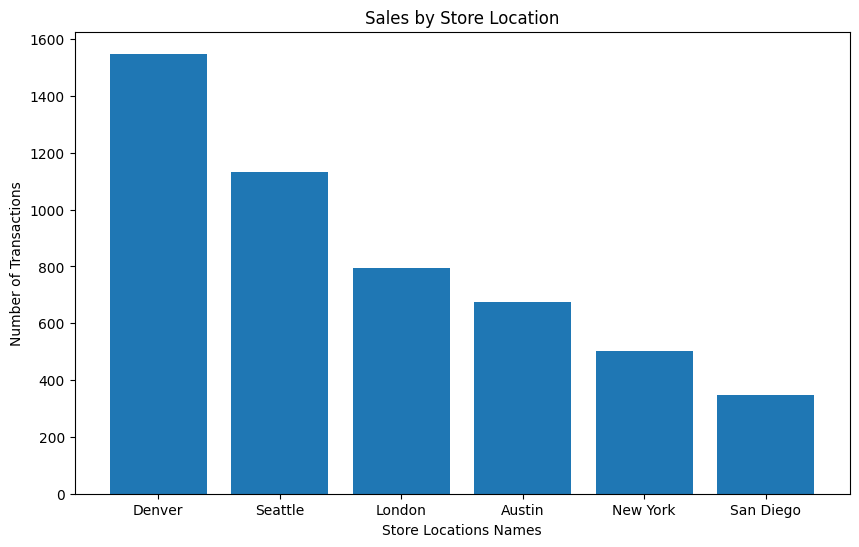

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(store_transactions_df["Store Location"], store_transactions_df["Total Transactions"])
plt.title("Sales by Store Location")
plt.ylabel("Number of Transactions")
plt.xlabel("Store Locations Names")

plt.show()